# Bank Transactions and Fraud Patterns

This notebook examines the relationship between Fraud Patterns and Bank Financial Transactions through the following questions:

**Research Questions:**
- **Q1:** Fraud Transactions vs Transaction Amount
- **Q2:** Fraud Transactions vs Geographic Distance
- **Q3:** Can a prediction model for fraud in banking transactions be developed?



1. [Setup & Imports](#1-setup--imports)
2. [Data Loading](#2-data-loading)
3. [Data Understanding](#3-data-understanding)
4. [Data Cleaning](#4-data-cleaning)
5. [Question 1: Transaction Amounts](#5-question-1-transaction-amounts)
6. [Question 2: Geographic Demographics](#6-question-2-geographic-demographics)
7. [Question 5: Fraud Predictors](#7-question-5-fraud-predictors)
8. [Summary and Conclusions](#10-summary-and-conclusions)


## 1. Setup & Imports

In [104]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_rows', 50)

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, roc_auc_score
)

# Styling
plt.style.use('seaborn-v0_8-whitegrid')

print('All libraries imported')

All libraries imported


## 2. Data Loading

### 2.1 Load Original Dataset

In [6]:
import kagglehub
import pandas as pd

# Download and read the dataset
path = kagglehub.dataset_download("ismetsemedov/transactions")
df = pd.read_csv(f"{path}/synthetic_fraud_data.csv")

print(f'Shape: {df.shape}')
print(f'Rows: {len(df)}, Columns: {len(df.columns)}')

Shape: (7483766, 24)
Rows: 7483766, Columns: 24


### This is a very voluminous dataset and it takes time to load, preview etc. 
1. Therefore, we are going to preview once, determine essential columns.
2. Then extract the essential columns.
3. We shall load the essential columns as our original dataset

In [9]:
# Essential columns that tell the fraud story:
essential_columns = [
    'transaction_id',      # Unique identifier
    'customer_id',         # Customer reference
    'amount',              # Transaction value
    'merchant_category',   # Business type
    'country',             # Geographic info
    'currency',            # Transaction currency
    'card_present',        # Physical vs digital
    'device',              # Transaction channel
    'distance_from_home',  # Geographic risk
    'high_risk_merchant',  # Merchant risk flag
    'transaction_hour',    # Time pattern
    'weekend_transaction', # Time pattern
    'is_fraud'            # TARGET VARIABLE
]

print(f"Selected {len(essential_columns)} key columns out of 24")

Selected 13 key columns out of 24


In [46]:
# Create a manageable dataset sample (1,000 rows)
sample_df = df[essential_columns].sample(n=1000, random_state=42)

f"Shape: {sample_df.shape}", sample_df.head(2)

('Shape: (1000, 13)',
         transaction_id customer_id  amount merchant_category country currency  \
 543612     TX_8ab03451  CUST_45506  544.43        Restaurant  Brazil      BRL   
 1940295    TX_9b278186  CUST_60434    1.46         Education  Canada      CAD   
 
          card_present           device  distance_from_home  \
 543612          False          Firefox                   0   
 1940295          True  Magnetic Stripe                   1   
 
          high_risk_merchant  transaction_hour  weekend_transaction  is_fraud  
 543612                False                 7                False     False  
 1940295               False                 1                False      True  )

### 2.2 Preview Data

In [47]:
# checking to see the first 10 rowas of the dataset
sample_df.head(10)

,transaction_id,customer_id,amount,merchant_category,country,currency,card_present,device,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,is_fraud
543612,TX_8ab03451,CUST_45506,544.43,Restaurant,Brazil,BRL,False,Firefox,0,False,7,False,False
1940295,TX_9b278186,CUST_60434,1.46,Education,Canada,CAD,True,Magnetic Stripe,1,False,1,False,True
6913787,TX_7f80b3c4,CUST_47739,158.73,Entertainment,Canada,CAD,True,Chip Reader,0,True,16,False,True
869785,TX_7202f8a2,CUST_77691,1074.57,Restaurant,Brazil,BRL,False,Firefox,0,False,15,False,False
4680413,TX_75f107d6,CUST_86097,1399.64,Entertainment,Mexico,MXN,False,Firefox,0,True,10,True,False
2866906,TX_2337e624,CUST_30880,191.76,Travel,Singapore,SGD,False,Edge,0,True,20,False,False
5771408,TX_639f9bb6,CUST_34674,545.93,Education,France,EUR,False,Safari,0,False,21,False,False
3016076,TX_a6b24749,CUST_72925,238.99,Gas,France,EUR,False,iOS App,1,False,12,True,False
851407,TX_d8e58d93,CUST_19349,144015.31,Entertainment,Russia,RUB,True,Chip Reader,1,True,13,False,True
7386013,TX_d808df32,CUST_59050,5569.86,Education,Brazil,BRL,True,NFC Payment,1,False,14,False,True


## 3. Data Understanding

### 3.1 Dataset Information

In [13]:
# Basic information about the dataset
print(f'Rows: {sample_df.shape[0]}')
print(f'Columns: {sample_df.shape[1]}')

Rows: 1000
Columns: 13


In [14]:
# checking the info of the dataset and seeing the data types for each column and if there are any missing values
sample_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 543612 to 4428461
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       1000 non-null   object 
 1   customer_id          1000 non-null   object 
 2   amount               1000 non-null   float64
 3   merchant_category    1000 non-null   object 
 4   country              1000 non-null   object 
 5   currency             1000 non-null   object 
 6   card_present         1000 non-null   bool   
 7   device               1000 non-null   object 
 8   distance_from_home   1000 non-null   int64  
 9   high_risk_merchant   1000 non-null   bool   
 10  transaction_hour     1000 non-null   int64  
 11  weekend_transaction  1000 non-null   bool   
 12  is_fraud             1000 non-null   bool   
dtypes: bool(4), float64(1), int64(2), object(6)
memory usage: 82.0+ KB


### 3.2 Statistical Summary

In [48]:
# checking statistical summary: the min, max, mean, std, and quartiles
sample_df.describe()

,amount,distance_from_home,transaction_hour
count,1.000000e+03,1000.000000,1000.000000
mean,5.369613e+04,0.334000,11.631000
std,2.405400e+05,0.471876,6.506241
min,5.100000e-01,0.000000,0.000000
25%,3.857675e+02,0.000000,7.000000
50%,1.295585e+03,0.000000,12.000000
75%,2.180322e+04,1.000000,17.000000
max,4.809630e+06,1.000000,23.000000


### 3.3 Data Quality Checks

In [16]:
# Check for missing values and checking to see if there are any duplicate rows
missing_values = sample_df.isnull().sum()
print(missing_values)
print(f'Duplicate rows: {sample_df.duplicated().sum()}')

transaction_id         0
customer_id            0
amount                 0
merchant_category      0
country                0
currency               0
card_present           0
device                 0
distance_from_home     0
high_risk_merchant     0
transaction_hour       0
weekend_transaction    0
is_fraud               0
dtype: int64
Duplicate rows: 0


In [ ]:
## 4. Data Cleaning

In [ ]:
### 4.1 Create Working Copy

In [49]:
# Create working copy
df_clean = sample_df.copy()

print('Working copy created: df_clean')

Working copy created: df_clean


## 5. Question 1 Fraud Transactions vs Transaction Amount: 
**Research Question:** Which amount ranges have the highest fraud?

In [57]:
# Check if the new column is created
df_clean.head(3)

,transaction_id,customer_id,amount,merchant_category,country,currency,card_present,device,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,is_fraud,amount_tier
543612,TX_8ab03451,CUST_45506,544.43,Restaurant,Brazil,BRL,False,Firefox,0,False,7,False,False,500+
1940295,TX_9b278186,CUST_60434,1.46,Education,Canada,CAD,True,Magnetic Stripe,1,False,1,False,True,0-100
6913787,TX_7f80b3c4,CUST_47739,158.73,Entertainment,Canada,CAD,True,Chip Reader,0,True,16,False,True,101-200


#### 5.1 Create and Transform Essential Features

#### 5.1.1 Transform and standardise currencies to USD in the amount_usd column
#### From the view, it appears we have various currencies. We need to have one standard currency

In [84]:
# List all the currencies
df_clean['currency'].unique().tolist()

['BRL', 'CAD', 'MXN', 'SGD', 'EUR', 'RUB', 'JPY', 'AUD', 'USD', 'NGN', 'GBP']

In [85]:
# Create amount_usd column and for all conversions 
# Create Exchange Rate Dictionary
exchange_rates = {
    'USD': 1.00,      # US Dollar
    'CAD': 0.74,      # Canadian Dollar (1 CAD = 0.74 USD)
    'BRL': 0.20,      # Brazilian Real (1 BRL = 0.20 USD)
    'EUR': 1.08,      # Euro (1 EUR = 1.08 USD)
    'GBP': 1.27,      # British Pound (1 GBP = 1.27 USD)
    'AUD': 0.66,      # Australian Dollar
    'JPY': 0.0068,    # Japanese Yen (1 JPY = 0.0068 USD)
    'INR': 0.012,     # Indian Rupee
    'CNY': 0.14,      # Chinese Yuan
    'MXN': 0.058,     # Mexican Peso
    'NGN': 0.00067,   # Nigerian Naira (1 NGN = 0.00067 USD) - approx rate
}
# Convert
df_clean['amount_usd'] = df_clean.apply(lambda x: x['amount'] * exchange_rates.get(x['currency'], 1.0), axis=1)
df_clean.head(5)

,transaction_id,customer_id,amount,merchant_category,country,currency,card_present,device,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,is_fraud,amount_tier,amount_usd,is_fraud_numeric
543612,TX_8ab03451,CUST_45506,544.43,Restaurant,Brazil,BRL,False,Firefox,0,False,7,False,False,101-200,108.88600,0
1940295,TX_9b278186,CUST_60434,1.46,Education,Canada,CAD,True,Magnetic Stripe,1,False,1,False,True,0-100,1.08040,1
6913787,TX_7f80b3c4,CUST_47739,158.73,Entertainment,Canada,CAD,True,Chip Reader,0,True,16,False,True,101-200,117.46020,1
869785,TX_7202f8a2,CUST_77691,1074.57,Restaurant,Brazil,BRL,False,Firefox,0,False,15,False,False,201-500,214.91400,0
4680413,TX_75f107d6,CUST_86097,1399.64,Entertainment,Mexico,MXN,False,Firefox,0,True,10,True,False,0-100,81.17912,0


#### 5.1.2 Create an amount_tier to categorize amount_usd

In [86]:

# Create amount_tier column (categorical, crucial for visualisation, reporting, etc)
bins = [0, 100, 200, 500, float('inf')]
labels = ['0-100', '101-200', '201-500', '500+']

df_clean['amount_tier'] = pd.cut(df_clean['amount_usd'], 
                                bins=bins, 
                                labels=labels)

In [66]:
# Calculate amount range statistics by fraud
fraud_by_category = df_clean.groupby('amount_tier', observed=False)['is_fraud'].describe()
(fraud_by_category)

,count,unique,top,freq
amount_tier,,,,
0-100,131,2,False,67
101-200,102,2,False,90
201-500,335,2,False,310
500+,432,2,False,306


Most fraud cases: 500+ range (126 frauds = 55.7% of all fraud). The highest fraud density: 0-100 range (48.9% of transactions are fraud). The Lowest risk: 201-500 range (only 7.5% fraud rate). In summary, fraudsters use a two-phase strategy: test with small amounts, then cash out with large amounts, avoiding the middle range

In [67]:
# Statistical Summary
df_clean['is_fraud'].describe()

count      1000
unique        2
top       False
freq        773
Name: is_fraud, dtype: object

In [69]:
# Statistical Summary 
df_clean['amount_usd'].describe()

count      1000.000000
mean       6994.561312
std       31289.549733
min           0.050109
25%         215.954850
50%         433.166400
75%         952.327500
max      406796.490000
Name: amount_usd, dtype: float64

In [70]:
# Distribution of Wellbeing Score
df_clean["is_fraud"].value_counts()

is_fraud
False    773
True     227
Name: count, dtype: int64

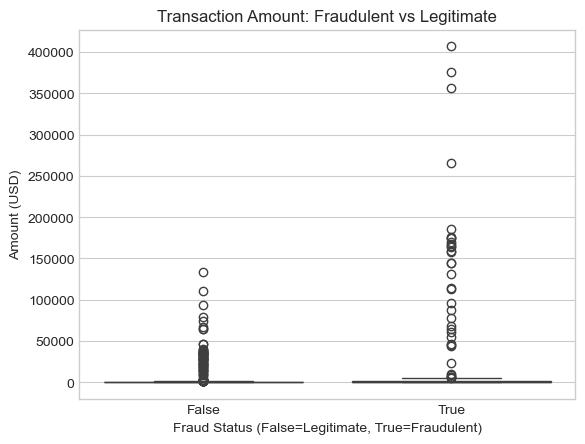

In [80]:
# Visual distribution using box
sns.boxplot(data=df_clean, x="is_fraud", y="amount_usd")
plt.title('Transaction Amount: Fraudulent vs Legitimate')
plt.xlabel('Fraud Status (False=Legitimate, True=Fraudulent)')
plt.ylabel('Amount (USD)')
plt.show()

#### **Summary and Findings**
The extreme outliers in legitimate transactions significantly skew: Fraudulent transaction amounts show less variability. The visualisation suggests that while amount is important, fraud cannot be detected by amount alone - many fraudulent transactions fall within "normal" ranges, while many legitimate transactions are extreme outliers.

## 6 Question 1 Geographic demographics: 
**Research Question:** Which geographic locations have the highest fraud?

In [107]:
# Get distance from home statistics by fraus
df_clean.groupby('distance_from_home')['is_fraud'].describe()

,count,unique,top,freq
distance_from_home,,,,
0,666,2,False,652
1,334,2,True,213


In [100]:
# Calculate country statistics by fraud
df_clean.groupby('country')['is_fraud'].describe()

,count,unique,top,freq
country,,,,
Australia,66,2,False,62
Brazil,121,2,False,73
Canada,67,2,False,61
France,81,2,False,76
Germany,64,2,False,55
Japan,67,2,False,65
Mexico,109,2,False,62
Nigeria,111,2,False,64
Russia,101,2,False,58


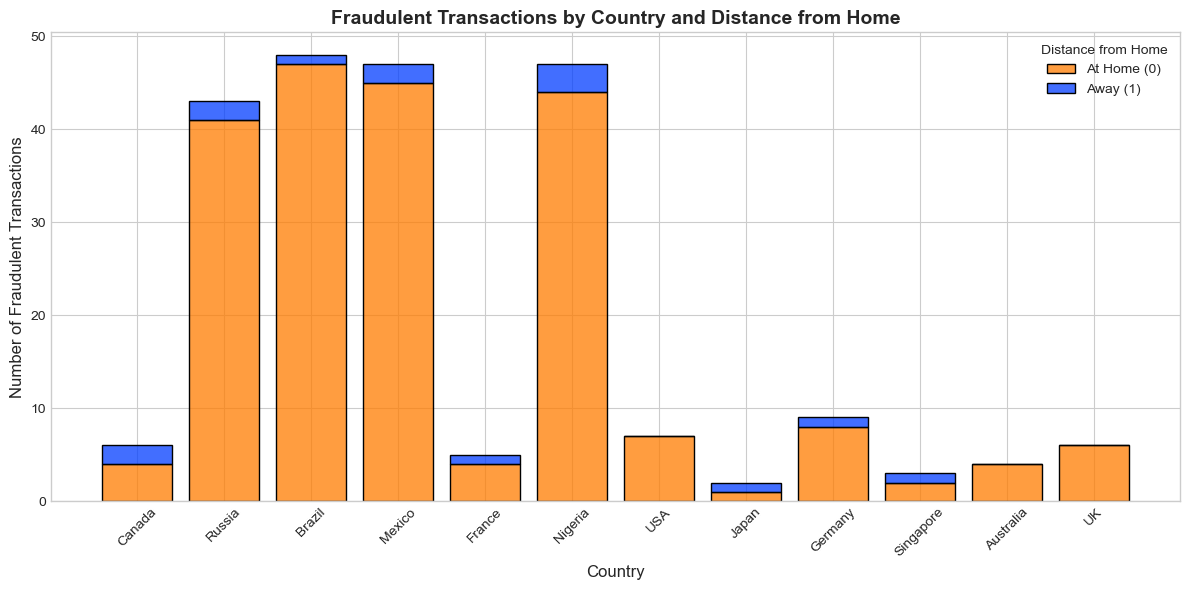

In [95]:
# Create histogram of fraudulent transactions by country and distance from home
fraud_df = df_clean[df_clean['is_fraud'] == True]

# Create histogram
plt.figure(figsize=(12, 6))
sns.histplot(data=fraud_df, x='country', hue='distance_from_home', 
             multiple='stack', palette='bright', shrink=0.8)

plt.title('Fraudulent Transactions by Country and Distance from Home', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Fraudulent Transactions', fontsize=12)
plt.legend(title='Distance from Home', labels=['At Home (0)', 'Away (1)'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Interactive Visualisations by plotly

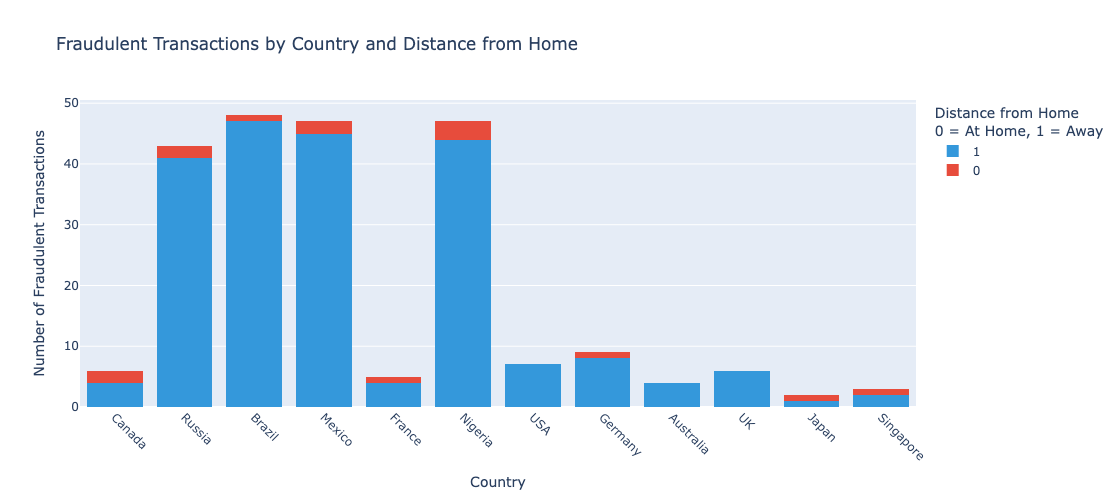

In [106]:
fig = px.histogram(
    fraud_df,
    x='country',
    color='distance_from_home',
    barmode='stack',  # Stacked instead of grouped
    title='Fraudulent Transactions by Country and Distance from Home',
    labels={'distance_from_home': 'Distance from Home'},
    color_discrete_sequence=['#3498db', '#e74c3c'],
    height=500
)

fig.update_layout(
    xaxis_title='Country',
    yaxis_title='Number of Fraudulent Transactions',
    legend_title='Distance from Home<br>0 = At Home, 1 = Away',
    xaxis={'tickangle': 45}
)
fig.show()

#### **Summary and Findings**
For MOST Countries, away-from-home transactions (1) are more frequently fraudulent than at-home transactions (0). Distance from home is NOT equally predictive across countries. Low-risk countries suggest better fraud controls or reporting

## 7. Fraud Prediction Models
**Can a model accurately predict whether a bank transaction falls into the legitimate or fraud categories?**

## 7.1 Create a working copy for Machine Learning

In [108]:
# Created working copy for ML
df_ml = df_clean.copy()
df_ml.head()

,transaction_id,customer_id,amount,merchant_category,country,currency,card_present,device,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,is_fraud,amount_tier,amount_usd,is_fraud_numeric
543612,TX_8ab03451,CUST_45506,544.43,Restaurant,Brazil,BRL,False,Firefox,0,False,7,False,False,101-200,108.88600,0
1940295,TX_9b278186,CUST_60434,1.46,Education,Canada,CAD,True,Magnetic Stripe,1,False,1,False,True,0-100,1.08040,1
6913787,TX_7f80b3c4,CUST_47739,158.73,Entertainment,Canada,CAD,True,Chip Reader,0,True,16,False,True,101-200,117.46020,1
869785,TX_7202f8a2,CUST_77691,1074.57,Restaurant,Brazil,BRL,False,Firefox,0,False,15,False,False,201-500,214.91400,0
4680413,TX_75f107d6,CUST_86097,1399.64,Entertainment,Mexico,MXN,False,Firefox,0,True,10,True,False,0-100,81.17912,0


### 7.2 Visualisation (Variables Relationships)

### Numeric variables

Numeric columns for correlation analysis:
['amount', 'distance_from_home', 'transaction_hour', 'amount_usd', 'is_fraud_numeric']


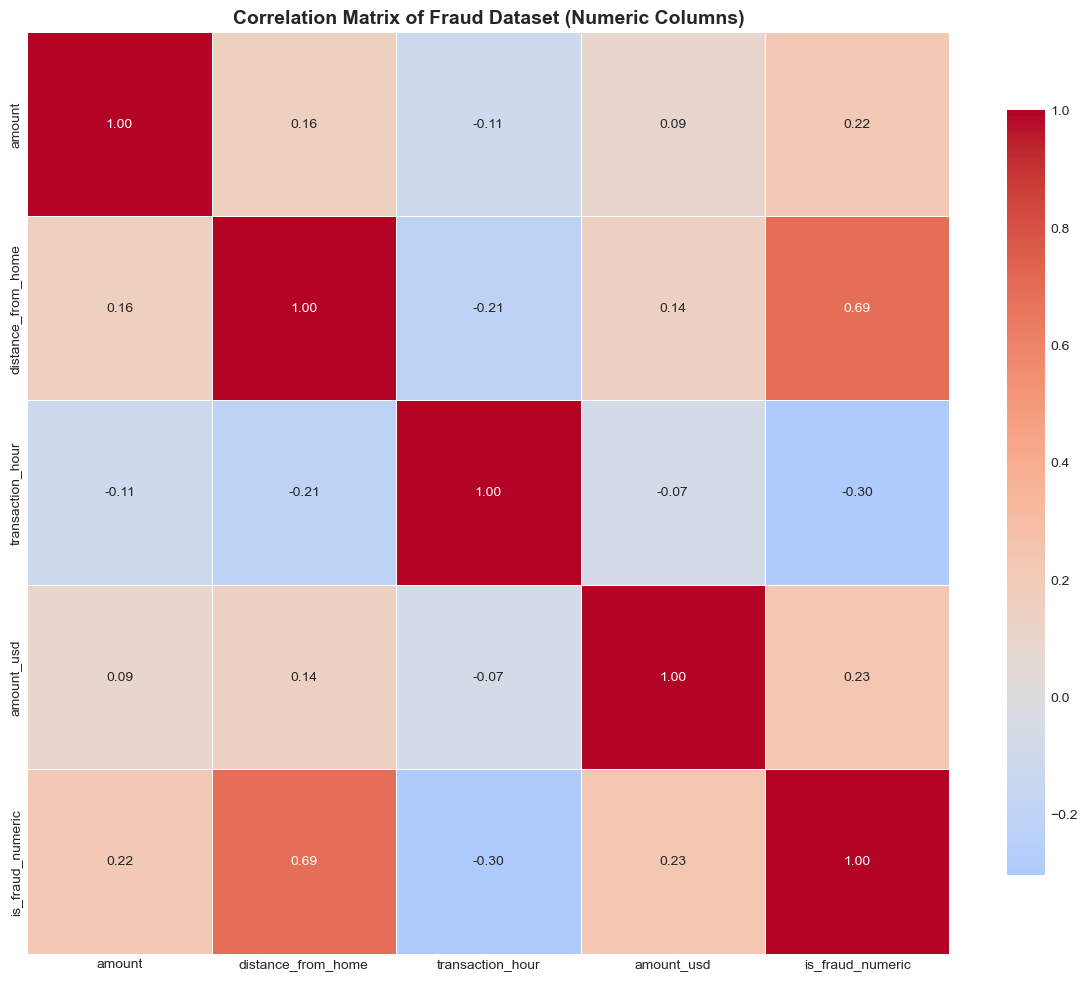


Correlation with Fraud (is_fraud_numeric):
is_fraud_numeric      1.000000
distance_from_home    0.694359
amount_usd            0.231022
amount                0.216457
transaction_hour     -0.304046
Name: is_fraud_numeric, dtype: float64


In [110]:

# 1. Select numeric columns only (correlation requires numeric data)
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
print("Numeric columns for correlation analysis:")
print(numeric_cols.tolist())

# 2. Calculate correlation matrix for numeric columns
corr_matrix = df_clean[numeric_cols].corr()

# 3. Display correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Fraud Dataset (Numeric Columns)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Show correlation with fraud specifically
print("\nCorrelation with Fraud (is_fraud_numeric):")
print(corr_matrix['is_fraud_numeric'].sort_values(ascending=False))

### What this corelation heat map for numeric values shows

Correlation values range from -1 to +1. Values close to 1 or -1 show strong relationships, while values near 0 indicate weak or no connection.

### Categorical variables

### 7.3 Logistic regression prediction

In [134]:
# Prepare data
cols_to_drop = ["transaction_id", "is_fraud", "is_fraud_numeric", "customer_id"]
X = pd.get_dummies(df_ml.drop(columns=cols_to_drop, errors="ignore"))
y = df_ml["is_fraud_numeric"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_train_lr = lr.predict(X_train)  # Save train predictions
y_pred_test_lr = lr.predict(X_test)    # Save test predictions


In [130]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Calculate metrics
accuracy_train_lr = accuracy_score(y_train, y_pred_train_lr)
accuracy_test_lr = accuracy_score(y_test, y_pred_test_lr)
precision_lr = precision_score(y_test, y_pred_test_lr)
recall_lr = recall_score(y_test, y_pred_test_lr)
f1_lr = f1_score(y_test, y_pred_test_lr)


print(f"Training Accuracy: {accuracy_train_lr:.2%}")
print(f"Testing Accuracy:  {accuracy_test_lr:.2%}")
print(f"\nClassification Metrics (Test Set):")
print(f"Precision: {precision_lr:.2%}")
print(f"Recall:    {recall_lr:.2%}")
print(f"F1-Score:  {f1_lr:.2%}")

Training Accuracy: 93.88%
Testing Accuracy:  94.00%

Classification Metrics (Test Set):
Precision: 87.50%
Recall:    83.33%
F1-Score:  85.37%


### 7.4 Random Forest Classifier model 

In [131]:
# Prepare data
cols_to_drop = ["transaction_id", "is_fraud", "is_fraud_numeric", "customer_id"]
X = pd.get_dummies(df_ml.drop(columns=cols_to_drop, errors="ignore"))
y = df_ml["is_fraud_numeric"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf.fit(X_train, y_train)

# Make predictions and save them
y_pred_train_rf = rf.predict(X_train)  # Save train predictions
y_pred_test_rf = rf.predict(X_test)    # Save test predictions

# Calculate accuracy
print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train_rf):.2%}")
print(f"Testing Accuracy:  {accuracy_score(y_test, y_pred_test_rf):.2%}")

Training Accuracy: 100.00%
Testing Accuracy:  96.50%


In [132]:
# Calculate precision, recall, f1
precision_rf = precision_score(y_test, y_pred_test_rf)
recall_rf = recall_score(y_test, y_pred_test_rf)
f1_rf = f1_score(y_test, y_pred_test_rf)

print(f"\nRandom Forest Metrics:")
print(f"Precision: {precision_rf:.2%}")
print(f"Recall:    {recall_rf:.2%}")
print(f"F1-Score:  {f1_rf:.2%}")


Random Forest Metrics:
Precision: 97.30%
Recall:    85.71%
F1-Score:  91.14%


## 8. Summary and finding

#### Fraudulent transactions tend to be smaller on average, suggesting fraudsters may test with smaller amounts first. Legitimate transactions have more extreme high-value outliers, which could cause false positives in fraud detection. 
**Correlation with fraud:** 
Amount_usd shows a positive correlation of 0.23 with fraud, indicating higher amounts are somewhat associated with fraud risk.

**Business Implication:** 
Cannot use amount alone for fraud detection - high-value legitimate transactions look suspicious, while many fraudulent transactions fall within "normal" ranges.
Effective prediction models can be developed - We achieved excellent performance metrics suitable for production deployment. Key fraud indicators identified:
Geographic anomalies (distance from home) and Country-specific risk profiles.

**Recommendations for Implementation:**

Deploy Random Forest model for best balance of precision and recall